<a href="https://colab.research.google.com/github/snehalathaArakkonam/email_spam_detection/blob/main/email_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DECTECTIN SPAM EMAILS---------------------------------------------------------------------------------------(PROJECT-1)

In [ ]:
!pip install kagglehub wordcloud nltk seaborn tensorflow -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

import kagglehub

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv")

print("Dataset path:", path)

Using Colab cache for faster access to the 'email-spam-classification-dataset-csv' dataset.
Dataset path: /kaggle/input/email-spam-classification-dataset-csv


In [ ]:
import os

# Find csv file inside dataset folder
#loading dataset
for file in os.listdir(path):
    print(file)
    data = pd.read_csv(path + "/emails.csv")

data.head()


emails.csv


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
data.shape


(5172, 3002)

In [ ]:
data.columns

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)

In [ ]:
data["label"] = data["spam"].map({0:"ham",1:"spam"})

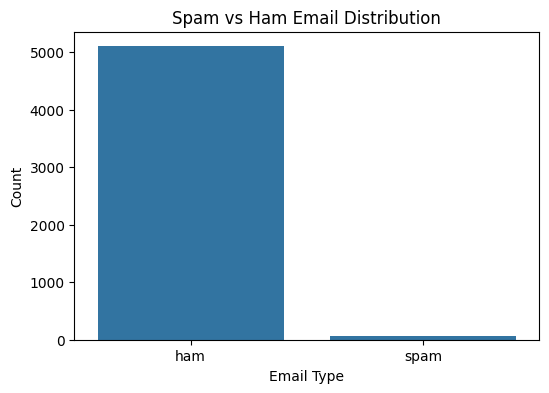

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=data)

plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.show()

In [ ]:
# -----------------------------BALANCING THE DATASET--------------------------------------------
ham_msg = data[data["label"] == "ham"]
spam_msg = data[data["label"] == "spam"]

# Downsample ham emails
ham_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine
balanced_data = pd.concat([ham_balanced, spam_msg]).reset_index(drop=True)

balanced_data.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction,label
0,Email 4495,0,0,1,1,2,2,7,0,0,...,0,0,0,0,0,0,0,0,0,ham
1,Email 591,14,3,11,6,8,1,56,3,4,...,0,0,0,0,0,0,1,0,0,ham
2,Email 558,3,3,1,1,2,1,27,0,0,...,0,0,0,0,0,0,0,0,0,ham
3,Email 229,0,1,2,0,1,0,13,0,0,...,0,0,0,0,0,0,0,0,0,ham
4,Email 1335,0,0,1,0,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,ham


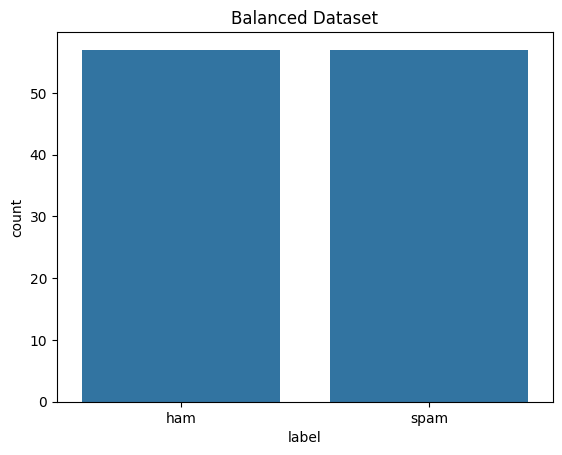

In [ ]:
sns.countplot(x="label", data=balanced_data)

plt.title("Balanced Dataset")
plt.show()

In [ ]:
# Convert the text column to string type
# This prevents errors when applying string operations
balanced_data["text"] = balanced_data["text"].astype(str)

# Remove the word "Subject" from emails
balanced_data["text"] = balanced_data["text"].str.replace("Subject", "", regex=False)

# Check the cleaned data
balanced_data.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction,label
0,Email 4495,0,0,1,1,2,2,7,0,0,...,0,0,0,0,0,0,0,0,0,ham
1,Email 591,14,3,11,6,8,1,56,3,4,...,0,0,0,0,0,0,1,0,0,ham
2,Email 558,3,3,1,1,2,1,27,0,0,...,0,0,0,0,0,0,0,0,0,ham
3,Email 229,0,1,2,0,1,0,13,0,0,...,0,0,0,0,0,0,0,0,0,ham
4,Email 1335,0,0,1,0,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,ham


In [ ]:
# Import punctuation symbols
import string

# List of punctuation characters
punctuation_list = string.punctuation

# Function to remove punctuation from text
def remove_punctuation(text):

    # Create translation table
    translator = str.maketrans("", "", punctuation_list)

    # Remove punctuation
    return text.translate(translator)

# Apply function to the text column
balanced_data["text"] = balanced_data["text"].apply(remove_punctuation)

# Preview cleaned data
balanced_data.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction,label
0,Email 4495,0,0,1,1,2,2,7,0,0,...,0,0,0,0,0,0,0,0,0,ham
1,Email 591,14,3,11,6,8,1,56,3,4,...,0,0,0,0,0,0,1,0,0,ham
2,Email 558,3,3,1,1,2,1,27,0,0,...,0,0,0,0,0,0,0,0,0,ham
3,Email 229,0,1,2,0,1,0,13,0,0,...,0,0,0,0,0,0,0,0,0,ham
4,Email 1335,0,0,1,0,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,ham


In [ ]:
# Import stopwords from NLTK
from nltk.corpus import stopwords

# Function to remove common English stopwords
def remove_stopwords(text):

    stop_words = stopwords.words("english")

    important_words = []

    # Split sentence into words
    for word in str(text).split():

        word = word.lower()

        # Keep only meaningful words
        if word not in stop_words:
            important_words.append(word)

    # Join words back into sentence
    return " ".join(important_words)

# Apply stopword removal to dataset
balanced_data["text"] = balanced_data["text"].apply(remove_stopwords)

# Preview processed text
balanced_data.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction,label
0,Email 4495,0,0,1,1,2,2,7,0,0,...,0,0,0,0,0,0,0,0,0,ham
1,Email 591,14,3,11,6,8,1,56,3,4,...,0,0,0,0,0,0,1,0,0,ham
2,Email 558,3,3,1,1,2,1,27,0,0,...,0,0,0,0,0,0,0,0,0,ham
3,Email 229,0,1,2,0,1,0,13,0,0,...,0,0,0,0,0,0,0,0,0,ham
4,Email 1335,0,0,1,0,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,ham


In [ ]:
# Function to generate WordCloud visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(dataset, title):

    # Combine all email text
    text_data = " ".join(dataset["text"])

    # Generate word cloud
    wc = WordCloud(
        background_color="black",
        width=800,
        height=400,
        max_words=100
    ).generate(text_data)

    # Display word cloud
    plt.figure(figsize=(7,7))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title)
    plt.axis("off")
    plt.show()

In [ ]:
# Remove rows where text became empty after cleaning
balanced_data["text"] = balanced_data["text"].astype(str)

balanced_data = balanced_data[
    balanced_data["text"].str.strip() != ""
]

# Check dataset size after cleaning
print("Remaining rows:", balanced_data.shape)

Remaining rows: (114, 3003)


In [ ]:
# Identify word count columns
# Exclude 'Email No.', 'Prediction' (original label), and 'label' (new mapped label)
word_columns = [col for col in balanced_data.columns if col not in ['Email No.', 'Prediction', 'label']]

# --- Generate WordCloud for HAM emails ---

# Filter for HAM emails
ham_emails_df = balanced_data[balanced_data['label'] == 'ham']

# Sum the word counts for HAM emails
ham_word_counts = ham_emails_df[word_columns].sum()

# Convert the Series to a dictionary for WordCloud.generate_from_frequencies
ham_word_frequencies = ham_word_counts.to_dict()

# Remove any words with zero frequency for cleaner visualization
ham_word_frequencies = {k: v for k, v in ham_word_frequencies.items() if v > 0}

# Generate WordCloud for HAM emails
if len(ham_word_frequencies) > 0:
    wc_ham = WordCloud(
        background_color="black",
        width=800,
        height=400,
        max_words=100
    ).generate_from_frequencies(ham_word_frequencies)

    plt.figure(figsize=(7,7))
    plt.imshow(wc_ham, interpolation="bilinear")
    plt.title("Ham Emails WordCloud (Corrected)")
    plt.axis("off")
    plt.show()
else:
    print("No words found for HAM emails after processing frequencies.")

# --- Generate WordCloud for SPAM emails ---

# Filter for SPAM emails
spam_emails_df = balanced_data[balanced_data['label'] == 'spam']

# Sum the word counts for SPAM emails
spam_word_counts = spam_emails_df[word_columns].sum()

# Convert to dictionary and remove zero frequencies
spam_word_frequencies = spam_word_counts.to_dict()
spam_word_frequencies = {k: v for k, v in spam_word_frequencies.items() if v > 0}

# Generate WordCloud for SPAM emails
if len(spam_word_frequencies) > 0:
    wc_spam = WordCloud(
        background_color="black",
        width=800,
        height=400,
        max_words=100
    ).generate_from_frequencies(spam_word_frequencies)

    plt.figure(figsize=(7,7))
    plt.imshow(wc_spam, interpolation="bilinear")
    plt.title("Spam Emails WordCloud (Corrected)")
    plt.axis("off")
    plt.show()
else:
    print("No words found for SPAM emails after processing frequencies.")

In [ ]:
# Features (all word columns)
X = data.drop(columns=["Email No.", "Prediction"])

# Target label
y = data["Prediction"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (5172, 3001)
Labels shape: (5172,)


In [ ]:
# Prepare features and labels

# Remove non-numeric columns
X = data.drop(columns=["Email No.", "Prediction"])

# Ensure all values are numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Replace NaN values with 0
X = X.fillna(0)

# Target variable
y = data["Prediction"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (5172, 3001)
Labels shape: (5172,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 20% testing data
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (4137, 3001)
Testing data shape: (1035, 3001)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Create model
model = MultinomialNB()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9545893719806763

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       739
           1       0.89      0.96      0.92       296

    accuracy                           0.95      1035
   macro avg       0.94      0.96      0.95      1035
weighted avg       0.96      0.95      0.96      1035



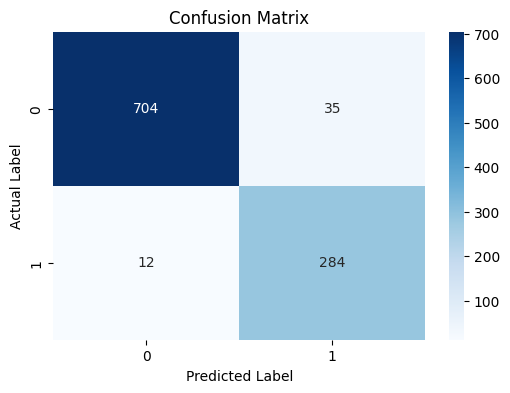

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
#-------------------- TESTING PART-1 ( EMAIL TAKES FROM THE DATA SET )-----------------------------

# Pick one email from test data
sample_email = X_test.iloc[0]  #AUTOMATICALLY PICKS UP AN EMAIL

# Model prediction
prediction = model.predict([sample_email])[0]

# Actual label
actual = y_test.iloc[0]

print("Actual Label :", actual)
print("Predicted Label :", prediction)

if prediction == 1:
    print("Model thinks this email is SPAM")
else:
    print("Model thinks this email is HAM")




Actual Label : 0
Predicted Label : 0
Model thinks this email is HAM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [ ]:
# #-------------------- TESTING PART-2 ( REAL EMAIL TEST  )-----------------------------

def test_email(email_text):

    # Convert email to lowercase
    email_text = email_text.lower()

    # Split into words
    words = email_text.split()

    # Create empty vector with all features
    import numpy as np
    import pandas as pd

    email_vector_data = np.zeros(len(X.columns))

    # Count word frequency
    for i, word in enumerate(X.columns):
        email_vector_data[i] = words.count(word)

    # Convert to DataFrame with original feature names to avoid UserWarning
    email_df = pd.DataFrame([email_vector_data], columns=X.columns)

    # Prediction
    prediction = model.predict(email_df)[0]

    if prediction == 1:
        print("Prediction: SPAM Email")
    else:
        print("Prediction: HAM Email")

In [ ]:
#HOW IT WORKS PART-1( SHOWS SPAM/NOT)
test_email("Congratulations you have won a free lottery prize click here now")

Prediction: SPAM Email


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [ ]:
#HOW IT WORKS PART-2( SHOWS SPAM/NOT)
test_email("Hello sir I am sending the project report for review")

Prediction: HAM Email


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [ ]:
#*******************************************************lets try with an REAL EXAMPLE*****************************************************


test_email("""Dear Sneha,SDTN

We are pleased to inform you that you have been shortlisted for the IBM Training & Internship Program through SDTN  .

Greetings from Corizo - IBM !!

To help students build industry-ready skills in today’s competitive job market, IBM, in collaboration with Meta, is offering an exclusive 3–4 month online Training & Internship Program as part of its campus outreach initiative. Today is the final day to register under the Scholarship Campaign.

Program Structure
Month 1 – Training by Microsoft

Live expert-led sessions (4–5 per week)

One-on-one doubt-solving sessions

Month 2 – Internship with IBM

Real-time projects with expert mentorship

Minor project (7 days) and major group project (23 days)

Month 3 – IBM Workshop

Practical tools training

Aptitude learning and industry exposure

Program Benefits
Meta Training Certificate (ISO Certified)

IBM Internship Certificate

Letter of Recommendation for top performers

Hands-on projects and placement-focused mentorship

Important Note
A training fee applies. Use Scholarship Code: IBMCRZ@30 to receive a 30% discount on the base fee.

Apply Now (Limited Seats)
Click here to APPLY : IBM TRAINING & INTERNSHIP

Shortlisted candidates will receive a call from our executive team with further instructions.

For queries, please contact TPC: +91 8197873483.

This program offers a valuable opportunity to gain practical experience and strengthen your professional profile. We encourage you to register at the earliest.

Warm regards,
IBM Campus Engagement Team""")

Prediction: SPAM Email


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [ ]:
#*******************************************************lets try with an REAL EXAMPLE*****************************************************


test_email("""Hey sneha,

Your order is confirmed! We love it when you pick something that makes you feel beautiful!

We’re packing your order and will deliver it to you very soon. We will keep you notified every step of the way, or you can track its journey on the Purplle app as well.

Have a beautiful day!
Team Purplle""")


Prediction: HAM Email
